# Preparing Data

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from scipy.stats import norm, probplot
import matplotlib.pyplot as plt

df_by_movie = pd.read_csv("../../Data/3. AnalysisData/df_by_movie_v5.csv")

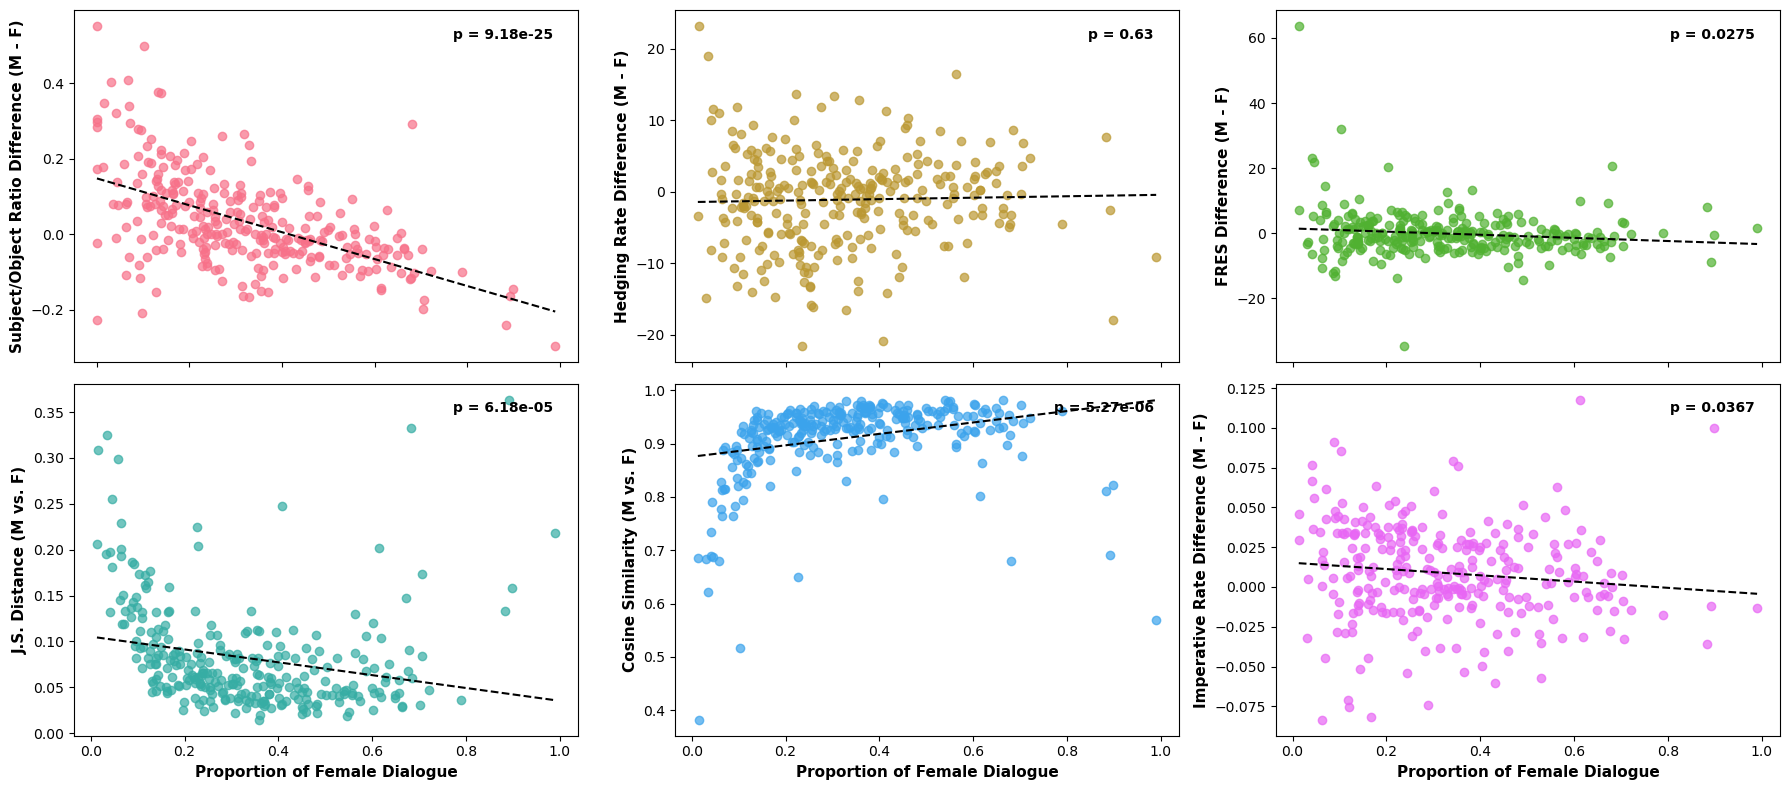

In [6]:
# Define metrics and their labels
metrics = [
    'ratio_diff',
    'hedge_diff',
    'flesch_diff_m_f',
    'jsd_m_f',
    'cossim',
    'diff_imperatives_normed'
]

labels = {
    'ratio_diff': 'Subject/Object Ratio Difference (M - F)',
    'hedge_diff': 'Hedging Rate Difference (M - F)',
    'flesch_diff_m_f': 'FRES Difference (M - F)',
    'jsd_m_f': 'J.S. Distance (M vs. F)',
    'cossim': 'Cosine Similarity (M vs. F)',
    'diff_imperatives_normed': 'Imperative Rate Difference (M - F)'
}

colors = sns.color_palette("husl", len(metrics))

# Create subplot grid
fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    ax = axs[i]
    df_subset = df_by_movie[['prop_fem', metric]].dropna()
    
    x = df_subset['prop_fem']
    y = df_subset[metric]
    
    # Scatter plot
    ax.scatter(x, y, color=colors[i], alpha=0.7)

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=1.5)

    ax.text(
    0.95, 0.95,
    f'p = {p_value:.3g}',
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    fontweight='bold'
)

    
    # Y label
    ax.set_ylabel(labels[metric], fontsize=11, fontweight='bold')

    # X label only for bottom row
    if i >= 3:
        ax.set_xlabel("Proportion of Female Dialogue", fontsize=11, fontweight='bold')
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])



# Final layout
plt.tight_layout()
plt.show()

# Fit OLS to each


--- Subject/Object Ratio Difference (M - F) ---
Slope: -0.3565
95% CI for slope: [-0.4187, -0.2944]
                            OLS Regression Results                            
Dep. Variable:             ratio_diff   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     127.5
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           9.18e-25
Time:                        11:31:38   Log-Likelihood:                 246.17
No. Observations:                 293   AIC:                            -488.3
Df Residuals:                     291   BIC:                            -481.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

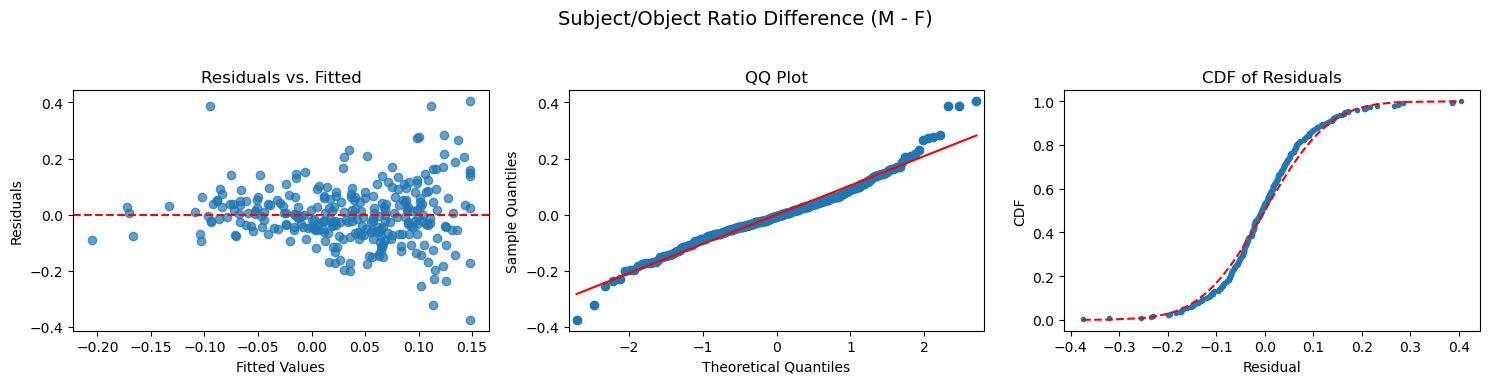


--- Hedging Rate Difference (M - F) ---
Slope: 1.0114
95% CI for slope: [-3.1111, 5.1340]
                            OLS Regression Results                            
Dep. Variable:             hedge_diff   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.2332
Date:                Wed, 06 Aug 2025   Prob (F-statistic):              0.630
Time:                        11:31:39   Log-Likelihood:                -949.57
No. Observations:                 286   AIC:                             1903.
Df Residuals:                     284   BIC:                             1910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

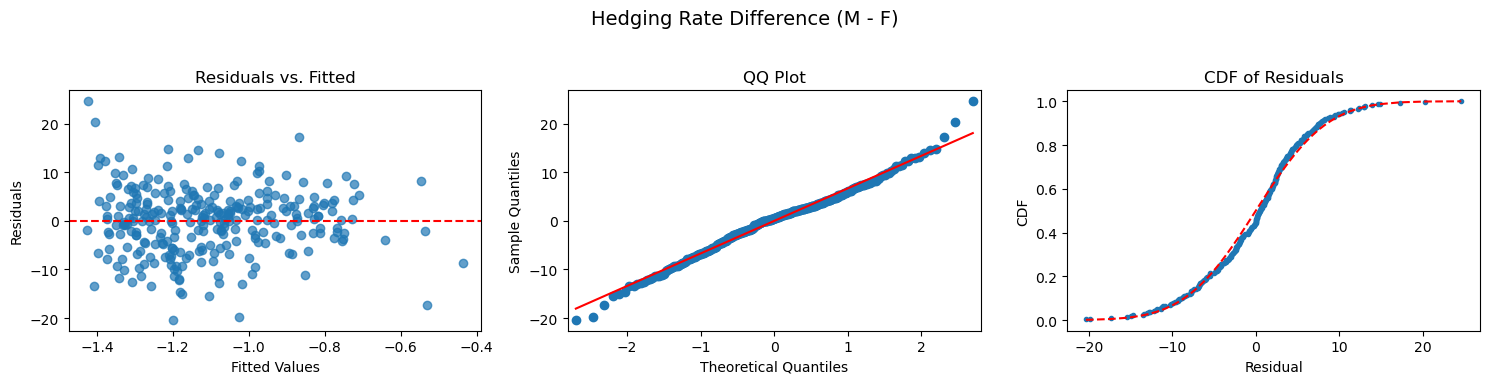


--- FRES Difference (M - F) ---
Slope: -4.8170
95% CI for slope: [-9.0974, -0.5366]
                            OLS Regression Results                            
Dep. Variable:        flesch_diff_m_f   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     4.907
Date:                Wed, 06 Aug 2025   Prob (F-statistic):             0.0275
Time:                        11:31:39   Log-Likelihood:                -960.32
No. Observations:                 286   AIC:                             1925.
Df Residuals:                     284   BIC:                             1932.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

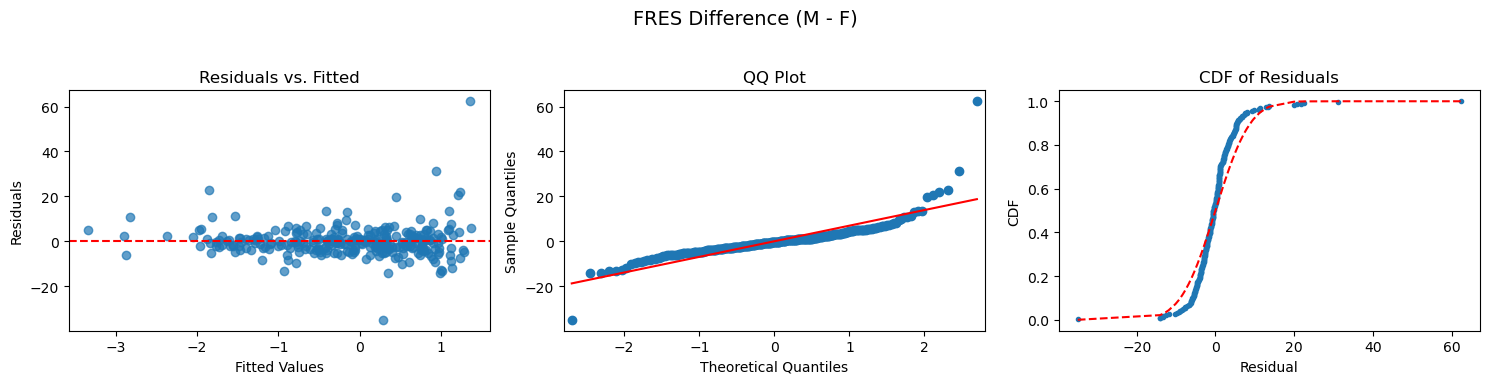


--- J.S. Distance (M vs. F) ---
Slope: -0.0700
95% CI for slope: [-0.1039, -0.0361]
                            OLS Regression Results                            
Dep. Variable:                jsd_m_f   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     16.54
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           6.18e-05
Time:                        11:31:39   Log-Likelihood:                 423.55
No. Observations:                 286   AIC:                            -843.1
Df Residuals:                     284   BIC:                            -835.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

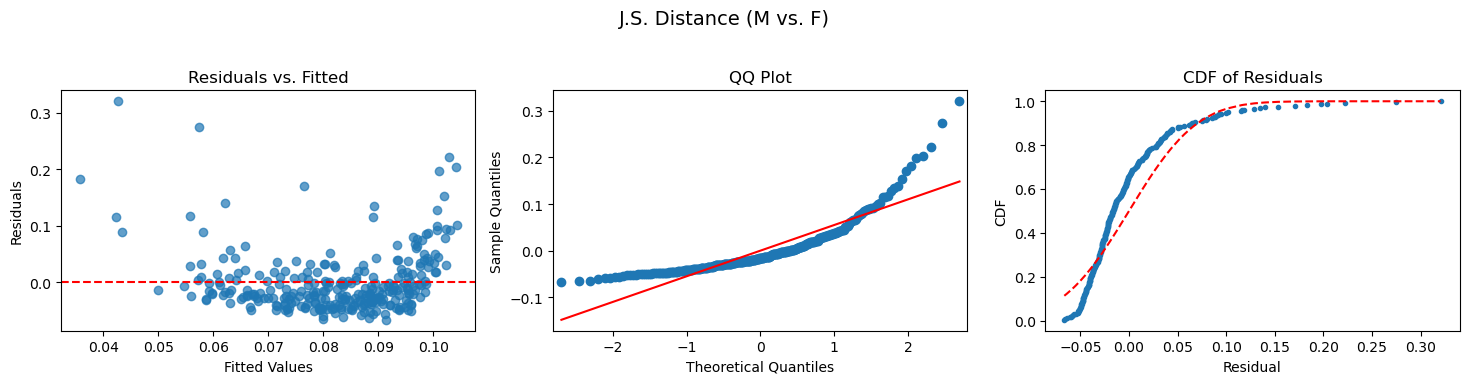


--- Cosine Similarity (M vs. F) ---
Slope: 0.1070
95% CI for slope: [0.0617, 0.1524]
                            OLS Regression Results                            
Dep. Variable:                 cossim   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     21.55
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           5.27e-06
Time:                        11:31:39   Log-Likelihood:                 339.99
No. Observations:                 286   AIC:                            -676.0
Df Residuals:                     284   BIC:                            -668.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

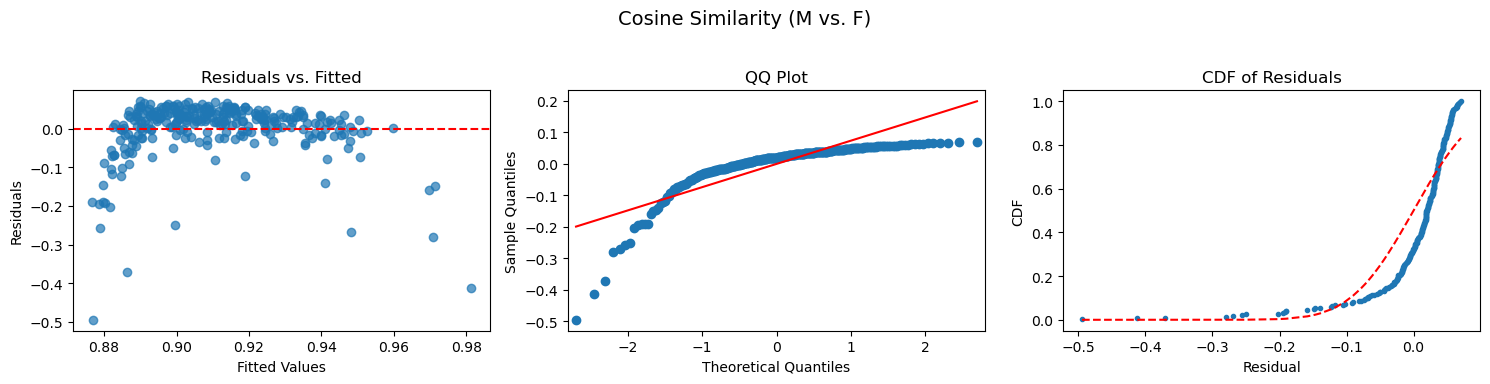


--- Imperative Rate Difference (M - F) ---
Slope: -0.0197
95% CI for slope: [-0.0381, -0.0012]
                               OLS Regression Results                              
Dep. Variable:     diff_imperatives_normed   R-squared:                       0.015
Model:                                 OLS   Adj. R-squared:                  0.012
Method:                      Least Squares   F-statistic:                     4.404
Date:                     Wed, 06 Aug 2025   Prob (F-statistic):             0.0367
Time:                             11:31:39   Log-Likelihood:                 597.37
No. Observations:                      286   AIC:                            -1191.
Df Residuals:                          284   BIC:                            -1183.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.0

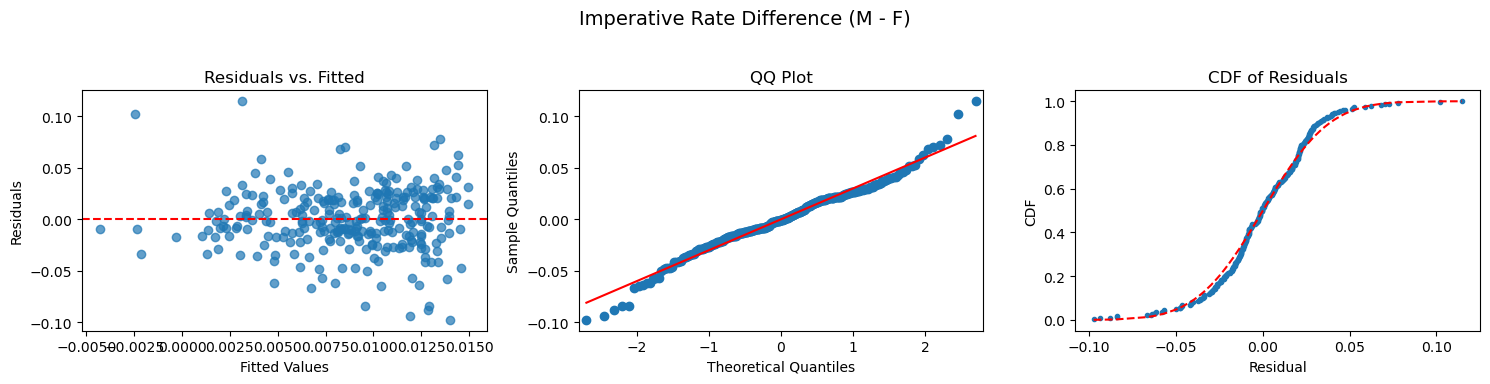

In [7]:
for i, metric in enumerate(metrics):
    df_subset = df_by_movie[['prop_fem', metric]].dropna()
    x = df_subset['prop_fem']
    y = df_subset[metric]

    # Add constant for OLS intercept
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    fitted_vals = model.fittedvalues
    residuals = model.resid
    slope = model.params['prop_fem']
    conf_int = model.conf_int().loc['prop_fem']

    print(f"\n--- {labels[metric]} ---")
    print(f"Slope: {slope:.4f}")
    print(f"95% CI for slope: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")
    print(model.summary())

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Residuals vs. Fitted
    axs[0].scatter(fitted_vals, residuals, alpha=0.7)
    axs[0].axhline(0, color='red', linestyle='--')
    axs[0].set_title('Residuals vs. Fitted')
    axs[0].set_xlabel('Fitted Values')
    axs[0].set_ylabel('Residuals')
    
    # 2. QQ Plot
    sm.qqplot(residuals, line='s', ax=axs[1])
    axs[1].set_title('QQ Plot')
    
    # 3. CDF Plot of Residuals
    sorted_resid = np.sort(residuals)
    cdf = np.arange(1, len(sorted_resid)+1) / len(sorted_resid)
    axs[2].plot(sorted_resid, cdf, marker='.', linestyle='none')
    axs[2].plot(sorted_resid, norm.cdf(sorted_resid, loc=np.mean(residuals), scale=np.std(residuals)), 'r--')
    axs[2].set_title('CDF of Residuals')
    axs[2].set_xlabel('Residual')
    axs[2].set_ylabel('CDF')
    
    plt.suptitle(labels[metric], fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Conclusion
### Subject/object
- negative relationship between subj obj and female dialogue
- 95% CI for Slope: [-0.4187, -0.2944]
- The true value of the slope is almost certainly negative (significant effect).
- R-squared: 0.305 (strong)
- p-value for slope: < 0.001: The relationship is highly statistically significant.
- The residuals are not perfectly normal

### Hedging
- Slope: 1.01
- 95% CI: [-3.11, 5.13] (includes zero)
- R²: 0.001 (0.1% of variance explained — almost none)
- p-value: 0.630 (not significant)

 ---> No relationship

### FRES (not perfect fit)
- slope = -4.8170
- 95% CI [-9.0974, -0.5366]
- R^2 0.014 (small effect)

### JS Distance (doesn't fit OLS)
- Slope: -0.07
- 95% CI: [-0.104, -0.036] (does not include zero)
- R²: 0.055 (small effect)
- p-value: <0.001 (statistically significant)

### Cosine Similarity (doesn't fit OLS)
- Slope: 0.107
- 95% CI: [0.062, 0.152] (does not include zero)
- R²: 0.071 (7.1% of variance explained — small but meaningful)
- p-value: <0.001 (statistically significant)
statistically significant positive relationship

### Imperative Rate
- Slope: -0.0197
- 95% CI for slope: [-0.0381, -0.0012]
- small but statistically significant negative relationship
- effect is very small (R-squared = 0.015)
- residuals may not be perfectly normal

# fit other models and use likelihood estimation